POZNAMKY
- v takto jednoduchem setupu to funguje dobre 
- pokud mame malo podobnych outlieru tak vse slape jak ma
- v momente kdyz vytvorime cluster anomalii model ztraci schopnost je detekovat (alespon se zda)

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [125]:
np.random.seed(42)

In [126]:
rng = np.random.default_rng(42)
x = rng.uniform(-50, 50, 950)
y = 0.01 * x**2 + rng.normal(0, 2.5, 950)  # šum so σ = 2.0
dataset = np.column_stack((x, y))

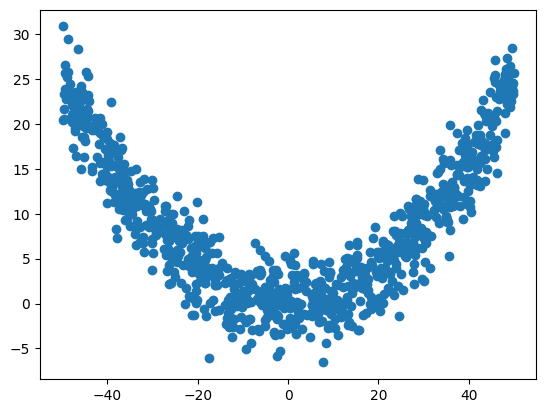

In [127]:
plt.scatter(dataset[:,0], dataset[:,1])

In [ ]:
x_outliers1 = np.random.randint(-350, -150, 1)/10
y_outliers1 = np.random.randint(250, 300, 1)/10

outs1 = np.column_stack((x_outliers1, y_outliers1))

x_outliers2 = np.random.randint(150, 350, 1)/10
y_outliers2 =  np.random.randint(250, 300, 1)/10
outs2 = np.column_stack((x_outliers2, y_outliers2))

In [143]:
outlier_data = np.vstack((outs1, outs2))
outlier_data

array([[-24.8,  26.8],
       [ 22.4,  26. ]])

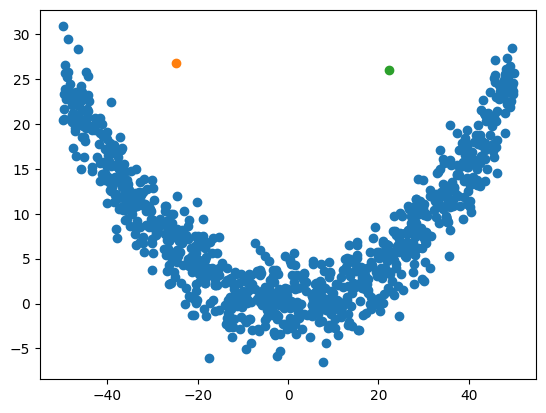

In [132]:
plt.scatter(dataset[:,0], dataset[:,1])
plt.scatter(outs1[:, 0], outs1[:, 1])
plt.scatter(outs2[:, 0], outs2[:, 1])
plt.show()

In [133]:
dataset = np.vstack((dataset, outs1, outs2))

In [134]:
import torch
import torch.nn as nn

class LinearAutoencoder(nn.Module):
    def __init__(self, input_dim=128, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [135]:
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn

ae = LinearAutoencoder(input_dim=dataset.shape[1], latent_dim=16)

tensor_data = torch.tensor(dataset, dtype=torch.float32)
loader = DataLoader(TensorDataset(tensor_data), batch_size=32, shuffle=True)

optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()
num_epochs = 50

losses = []

for epoch in range(num_epochs):
    for batch, in loader:
        optimizer.zero_grad()
        recon = ae(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
    losses.append(loss.detach().numpy())
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 1/50, Loss: 509.0774
Epoch 2/50, Loss: 410.6842
Epoch 3/50, Loss: 209.3589
Epoch 4/50, Loss: 109.8446
Epoch 5/50, Loss: 14.6959
Epoch 6/50, Loss: 5.2161
Epoch 7/50, Loss: 5.9293
Epoch 8/50, Loss: 5.4135
Epoch 9/50, Loss: 1.9486
Epoch 10/50, Loss: 2.9115
Epoch 11/50, Loss: 1.3025
Epoch 12/50, Loss: 3.7422
Epoch 13/50, Loss: 1.1382
Epoch 14/50, Loss: 1.7982
Epoch 15/50, Loss: 1.2795
Epoch 16/50, Loss: 2.1680
Epoch 17/50, Loss: 0.9426
Epoch 18/50, Loss: 0.7523
Epoch 19/50, Loss: 1.2184
Epoch 20/50, Loss: 1.0996
Epoch 21/50, Loss: 1.3819
Epoch 22/50, Loss: 0.6093
Epoch 23/50, Loss: 0.1933
Epoch 24/50, Loss: 0.7838
Epoch 25/50, Loss: 0.1730
Epoch 26/50, Loss: 0.1202
Epoch 27/50, Loss: 0.5217
Epoch 28/50, Loss: 0.5404
Epoch 29/50, Loss: 0.1181
Epoch 30/50, Loss: 0.1239
Epoch 31/50, Loss: 0.2084
Epoch 32/50, Loss: 0.2318
Epoch 33/50, Loss: 0.1448
Epoch 34/50, Loss: 0.1169
Epoch 35/50, Loss: 0.2040
Epoch 36/50, Loss: 0.1194
Epoch 37/50, Loss: 0.1355
Epoch 38/50, Loss: 0.1219
Epoch 39/50,

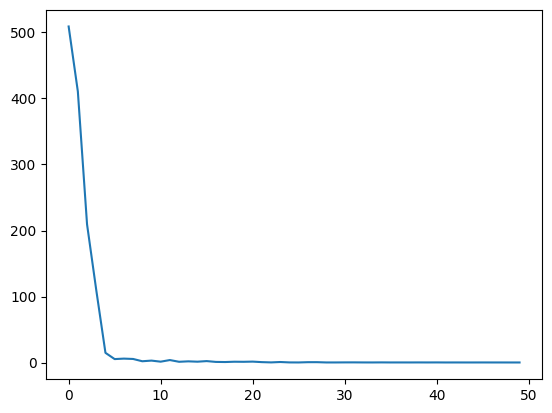

In [136]:
plt.plot(range(len(losses)), losses)

In [137]:
scores = []
ae.eval()
loss = nn.MSELoss()
for pt in dataset:
    pt = torch.tensor(pt).float()
    y_hat = ae(pt).detach()
    scores.append(loss(pt, y_hat))

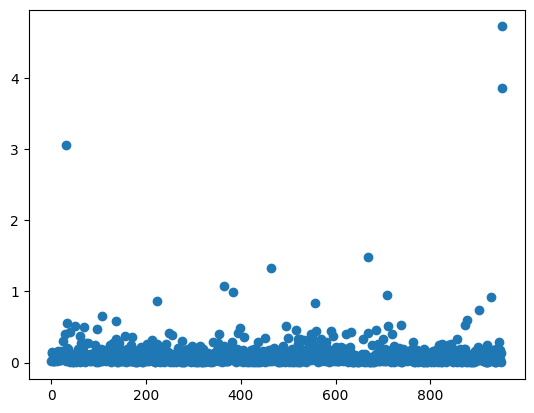

In [138]:
plt.scatter(range(len(scores)), scores)

In [142]:
out1 = sorted(scores)[-1]
out2 = sorted(scores)[-2]

possible_outliers = (dataset[scores.index(out1)], dataset[scores.index(out2)])

In [144]:
print('Was first outlier sclassified as outlier', possible_outliers[0] in outlier_data)
print('Was second outlier sclassified as outlier', possible_outliers[1] in outlier_data)

Was first outlier sclassified as outlier True
Was second outlier sclassified as outlier True


In [145]:
anomalies = []
for out in scores:
    if out > 3.5:
        anomalies.append(scores.index(out))

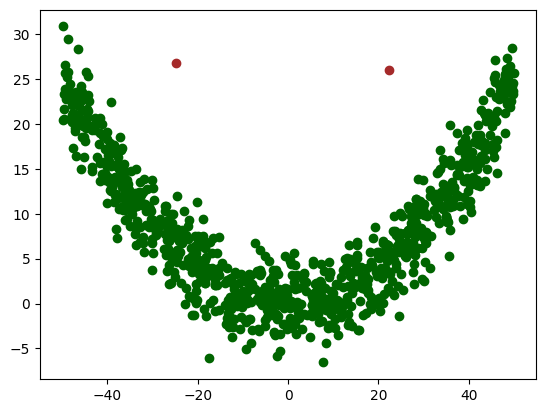

In [146]:
for idx, pt in enumerate(dataset):
    if idx in anomalies:
        plt.scatter(pt[0], pt[1], color='brown')
    else:
        plt.scatter(pt[0], pt[1], color='darkgreen')
plt.show()